# 📧 SpamAssassin Dataset — Exploratory Data Analysis (EDA)

**Dataset:** SpamAssassin (5,796 emails)
**Target:** `0` = Ham (Legitimate) | `1` = Spam

### Table of Contents
1. [Imports & Setup](#1)
2. [Load Data & Basic Info](#2)
3. [Class Distribution](#3)
4. [Email Length Analysis](#4)
5. [Word Count Analysis](#5)
6. [Character Level Analysis](#6)
7. [Top Most Frequent Words](#7)
8. [Word Cloud](#8)
9. [Unique Words Analysis](#9)
10. [Punctuation & Special Characters](#10)
11. [Email Header Analysis](#11)
12. [Correlation & Summary](#12)

---
## 1. Imports & Setup <a id='1'></a>

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

SPAM_COLOR = '#E74C3C'
HAM_COLOR  = '#2E86C1'

print('✅ All imports successful')

✅ All imports successful


---
## 2. Load Data & Basic Info <a id='2'></a>

In [2]:
df = pd.read_csv('../Files/spam_assassin.csv')

print('='*50)
print('DATASET BASIC INFO')
print('='*50)
print(f'Total Emails  : {df.shape[0]:,}')
print(f'Total Columns : {df.shape[1]}')
print(f'Columns       : {df.columns.tolist()}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('Missing Values:')
print(df.isnull().sum())
print()
print('Duplicate Rows:', df.duplicated().sum())
df.head(5)

DATASET BASIC INFO
Total Emails  : 5,796
Total Columns : 2
Columns       : ['text', 'target']

Data Types:
text      object
target     int64
dtype: object

Missing Values:
text      0
target    0
dtype: int64

Duplicate Rows: 467


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [3]:
# Add label column for readability
df['label'] = df['target'].map({0: 'Ham', 1: 'Spam'})

print('Sample Ham email:')
print('-'*60)
print(df[df['label']=='Ham']['text'].iloc[0][:400])
print()
print('Sample Spam email:')
print('-'*60)
print(df[df['label']=='Spam']['text'].iloc[0][:400])

Sample Ham email:
------------------------------------------------------------
From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single

Sample Spam email:
------------------------------------------------------------
From gort44@excite.com Mon Jun 24 17:54:21 2002 Return-Path: gort44@excite.com Delivery-Date: Tue Jun 4 05:31:16 2002 Received: from mandark.labs.netnoteinc.com ([213.105.180.140]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g544VFO20182 for <jm@jmason.org>; Tue, 4 Jun 2002 05:31:15 +0100 Received: from wi-poli.poli.cl ([200.54.149.34]) by mandark.labs.netnoteinc.com (8.11.2/8.11.2) with 


---
## 3. Class Distribution <a id='3'></a>

Class Distribution:
  Ham  (0) : 3,900  (67.3%)
  Spam (1) : 1,896  (32.7%)
  Imbalance Ratio : 2.06 : 1  (Ham:Spam)


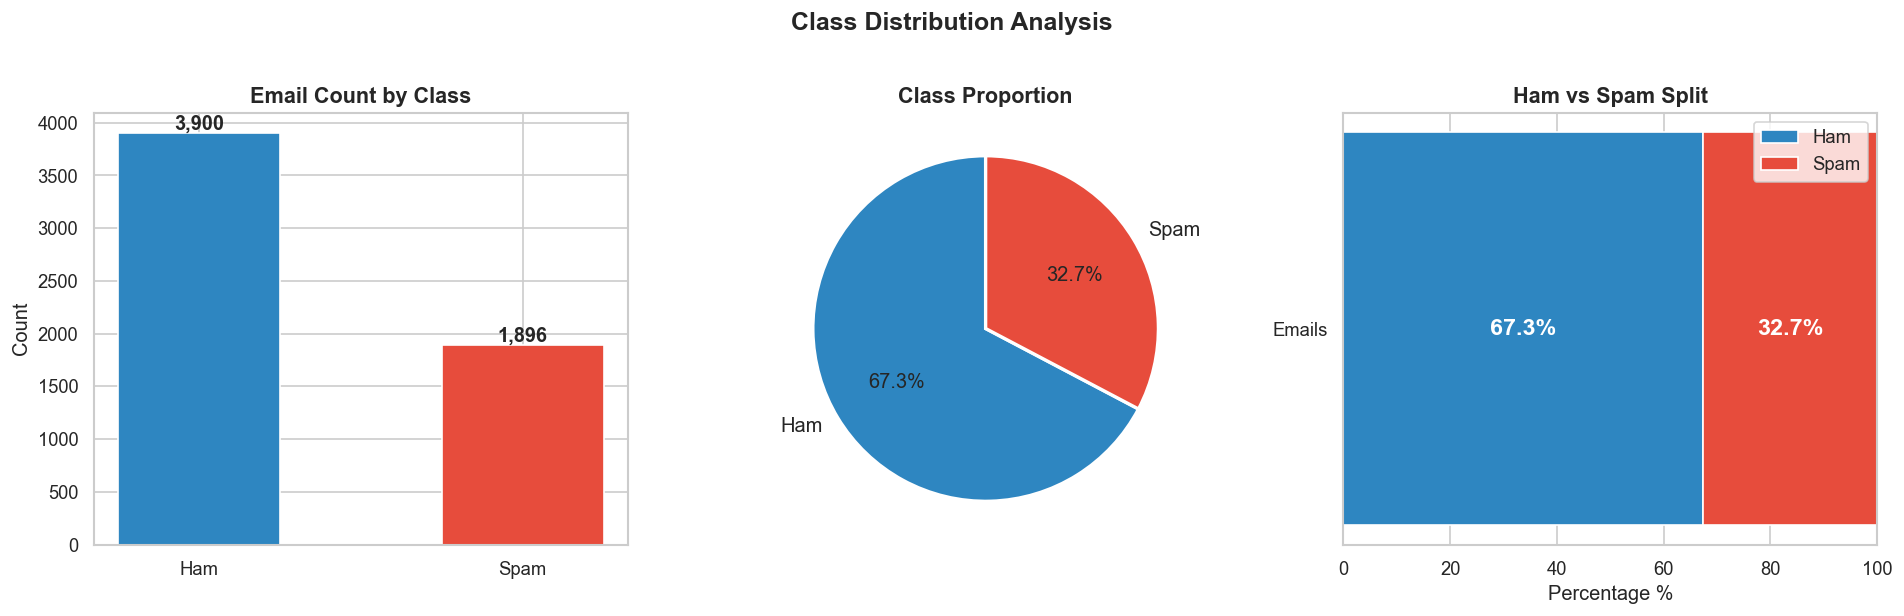

In [4]:
counts = df['label'].value_counts()
pcts   = df['label'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  Ham  (0) : {counts["Ham"]:,}  ({pcts["Ham"]:.1f}%)')
print(f'  Spam (1) : {counts["Spam"]:,}  ({pcts["Spam"]:.1f}%)')
print(f'  Imbalance Ratio : {counts["Ham"]/counts["Spam"]:.2f} : 1  (Ham:Spam)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=[HAM_COLOR, SPAM_COLOR], edgecolor='white', width=0.5)
axes[0].set_title('Email Count by Class', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=[HAM_COLOR, SPAM_COLOR],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Class Proportion', fontweight='bold', fontsize=13)

# Percentage bar
axes[2].barh(['Emails'], [pcts['Ham']], color=HAM_COLOR, label='Ham')
axes[2].barh(['Emails'], [pcts['Spam']], left=[pcts['Ham']], color=SPAM_COLOR, label='Spam')
axes[2].set_xlim(0, 100)
axes[2].set_xlabel('Percentage %')
axes[2].set_title('Ham vs Spam Split', fontweight='bold', fontsize=13)
axes[2].legend(loc='upper right')
axes[2].text(pcts['Ham']/2, 0, f"{pcts['Ham']:.1f}%", ha='center', va='center',
             color='white', fontweight='bold', fontsize=14)
axes[2].text(pcts['Ham'] + pcts['Spam']/2, 0, f"{pcts['Spam']:.1f}%",
             ha='center', va='center', color='white', fontweight='bold', fontsize=14)

plt.suptitle('Class Distribution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Email Length Analysis <a id='4'></a>

In [5]:
# Character count features
df['char_count']  = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()
df['line_count']  = df['text'].str.count('\n')
df['sent_count']  = df['text'].str.count(r'[.!?]')

print('Email Length Statistics by Class:')
print(df.groupby('label')[['char_count','word_count','line_count','sent_count']]
        .describe().round(1).to_string())

Email Length Statistics by Class:
      char_count                                                          word_count                                                   line_count                                    sent_count                                               
           count    mean     std    min     25%     50%     75%       max      count   mean    std   min    25%    50%    75%      max      count mean  std  min  25%  50%  75%  max      count   mean   std   min   25%    50%    75%     max
label                                                                                                                                                                                                                                         
Ham       3900.0  3483.1  3134.1  362.0  2435.2  3196.5  4049.2   92469.0     3900.0  405.7  484.9  45.0  262.0  347.0  454.0  15164.0     3900.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     3900.0  109.9  53.8   9.0  85.0  110.0  133.0  1180.0
Spam      

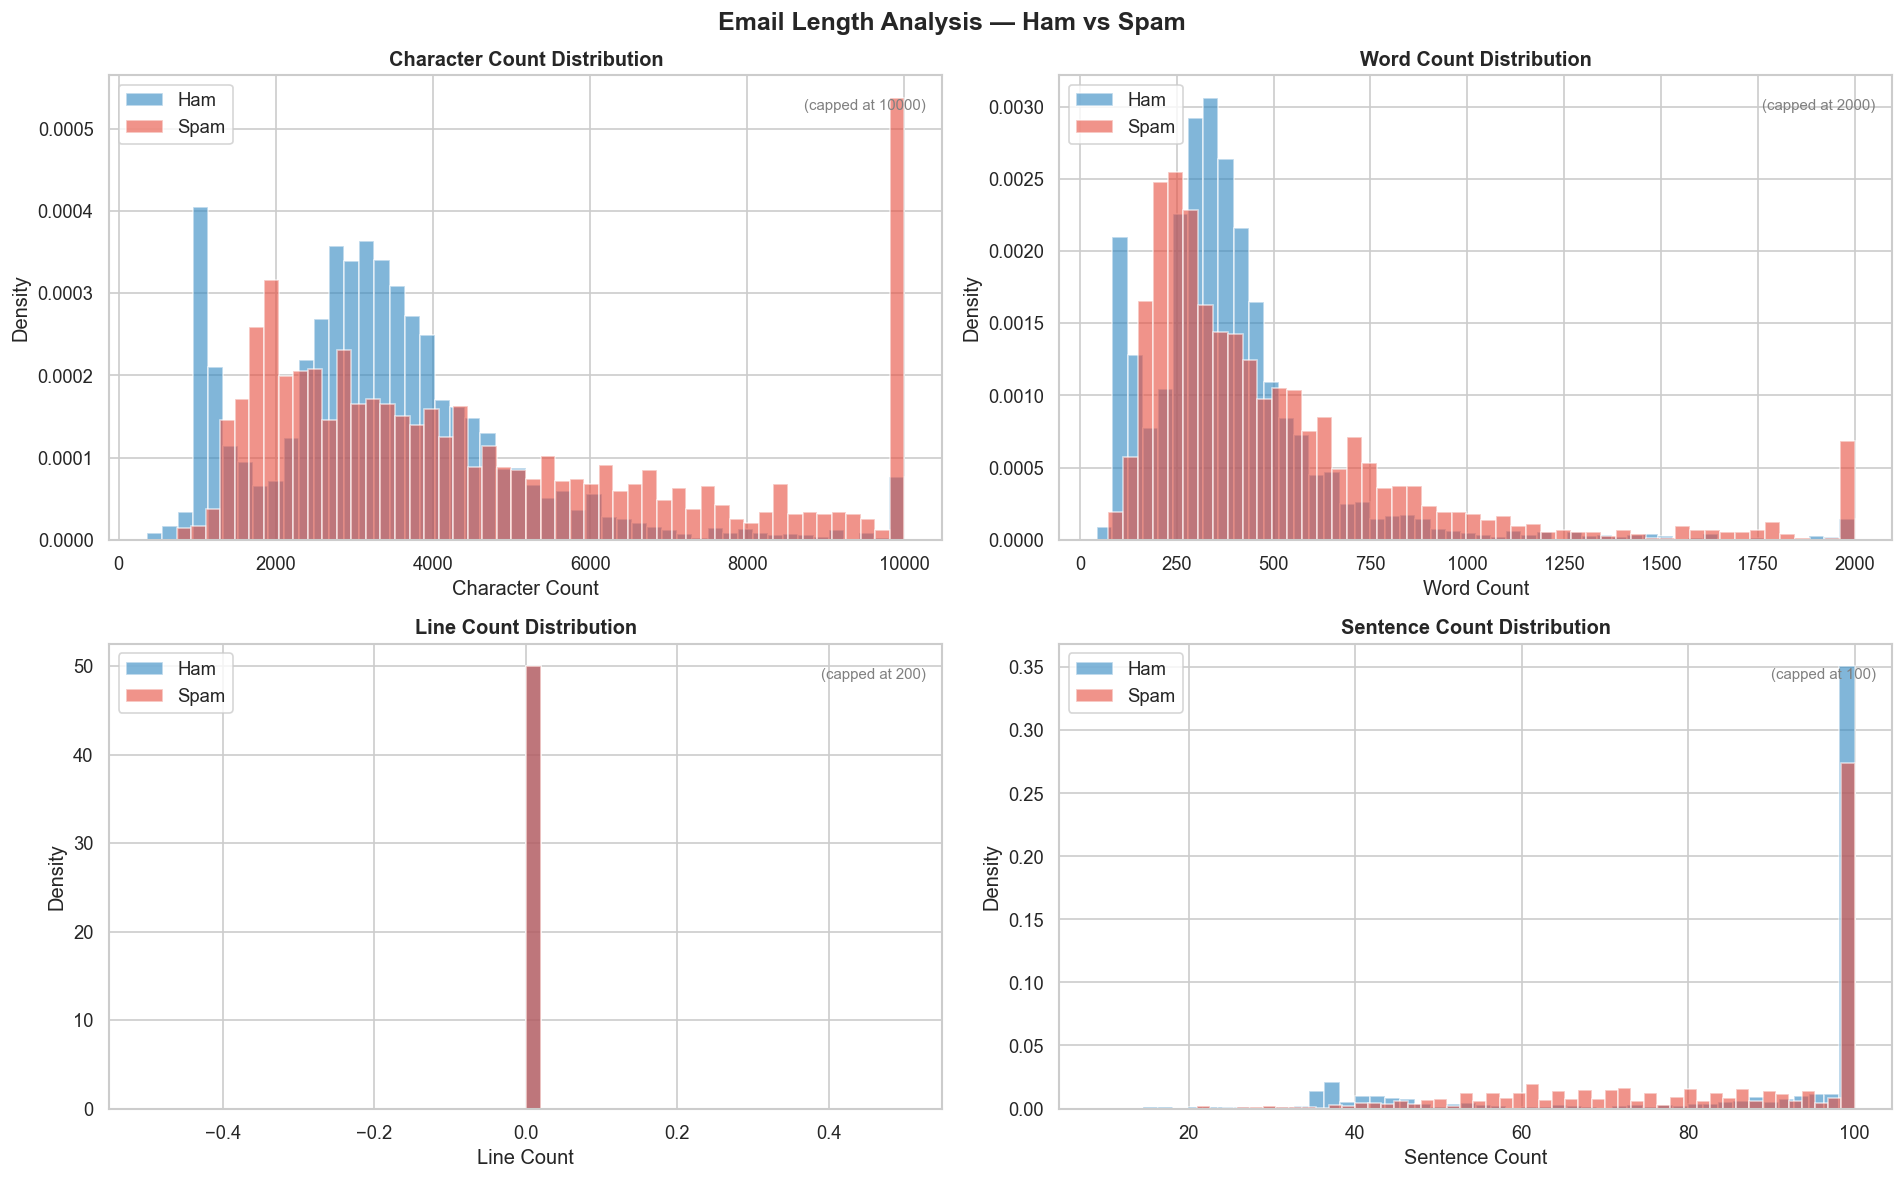

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

features = [
    ('char_count', 'Character Count', 10000),
    ('word_count', 'Word Count',      2000),
    ('line_count', 'Line Count',      200),
    ('sent_count', 'Sentence Count',  100),
]

for ax, (col, title, cap) in zip(axes.flat, features):
    for label, color in [('Ham', HAM_COLOR), ('Spam', SPAM_COLOR)]:
        data = df[df['label']==label][col].clip(upper=cap)
        ax.hist(data, bins=50, alpha=0.6, color=color,
                label=label, edgecolor='white', density=True)
    ax.set_title(f'{title} Distribution', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()
    ax.text(0.98, 0.95, f'(capped at {cap})',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='gray')

plt.suptitle('Email Length Analysis — Ham vs Spam', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_length_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

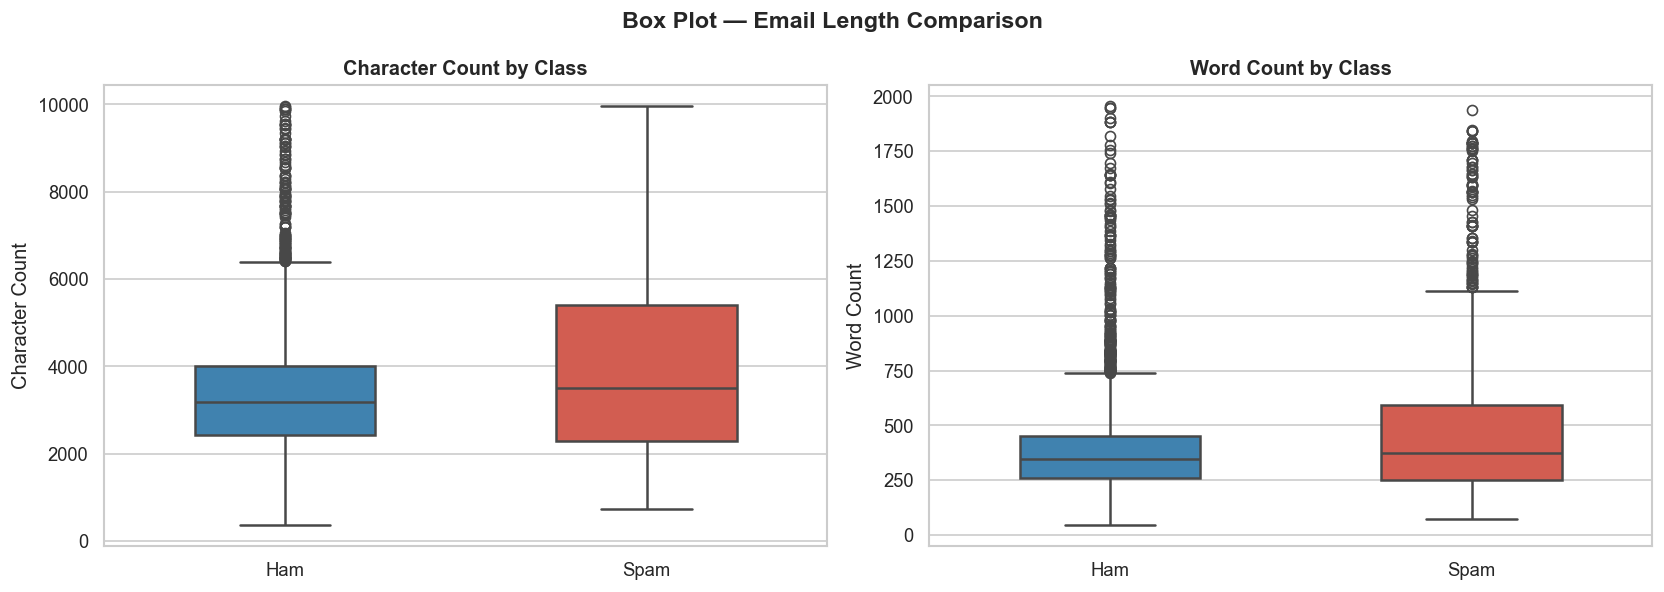

In [7]:
# Box plots for clean comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, cap in [
    (axes[0], 'char_count', 'Character Count', 10000),
    (axes[1], 'word_count', 'Word Count',      2000),
]:
    plot_df = df[df[col] <= cap]
    sns.boxplot(data=plot_df, x='label', y=col, ax=ax,
                palette={'Ham': HAM_COLOR, 'Spam': SPAM_COLOR},
                width=0.5, linewidth=1.5)
    ax.set_title(f'{title} by Class', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(title)

plt.suptitle('Box Plot — Email Length Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_boxplot_length.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Word Count Analysis <a id='5'></a>

Average Word Length by Class:
        count   mean    std    min    25%    50%    75%     max
label                                                          
Ham    3900.0  8.006  1.386  4.095  7.109  7.992   8.78  30.137
Spam   1896.0  9.556  5.511  4.691  7.158  8.605  10.08  72.044

Unique Word Ratio by Class:
        count   mean    std    min    25%    50%    75%    max
label                                                         
Ham    3900.0  0.621  0.061  0.141  0.588  0.627  0.658  0.933
Spam   1896.0  0.616  0.105  0.211  0.559  0.628  0.686  0.980


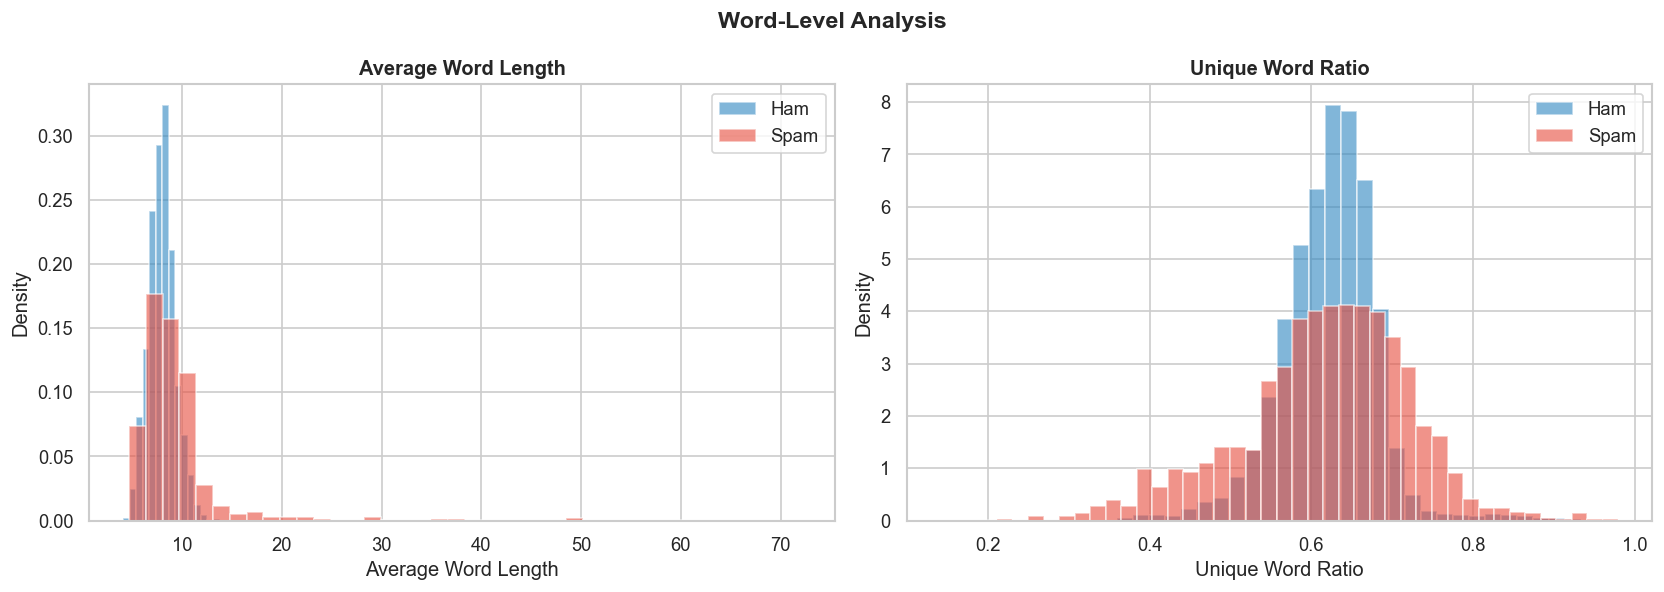

In [8]:
# Average words per sentence
df['avg_word_len']   = df['text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['unique_word_ratio'] = df['text'].apply(
    lambda x: len(set(x.lower().split())) / len(x.split()) if x.split() else 0)

print('Average Word Length by Class:')
print(df.groupby('label')['avg_word_len'].describe().round(3))
print()
print('Unique Word Ratio by Class:')
print(df.groupby('label')['unique_word_ratio'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'avg_word_len',     'Average Word Length'),
    (axes[1], 'unique_word_ratio','Unique Word Ratio'),
]:
    for label, color in [('Ham', HAM_COLOR), ('Spam', SPAM_COLOR)]:
        df[df['label']==label][col].plot(
            kind='hist', bins=40, ax=ax, alpha=0.6,
            color=color, label=label, edgecolor='white', density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Word-Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_word_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Character Level Analysis <a id='6'></a>

In [9]:
# Special character counts
df['digit_count']      = df['text'].apply(lambda x: sum(c.isdigit() for c in x))
df['upper_count']      = df['text'].apply(lambda x: sum(c.isupper() for c in x))
df['exclaim_count']    = df['text'].str.count('!')
df['question_count']   = df['text'].str.count(r'\?')
df['dollar_count']     = df['text'].str.count(r'\$')
df['url_count']        = df['text'].str.count(r'http')

# Ratios
df['upper_ratio']      = df['upper_count']  / df['char_count'].replace(0, 1)
df['digit_ratio']      = df['digit_count']  / df['char_count'].replace(0, 1)

char_features = ['exclaim_count','question_count','dollar_count',
                 'url_count','upper_ratio','digit_ratio']

print('Character-Level Features by Class:')
print(df.groupby('label')[char_features].mean().round(4).to_string())

Character-Level Features by Class:
       exclaim_count  question_count  dollar_count  url_count  upper_ratio  digit_ratio
label                                                                                  
Ham           0.7169          3.3528        0.7033     3.8300       0.0612       0.1052
Spam          6.4066          2.6746        3.9066     6.1904       0.1043       0.1018


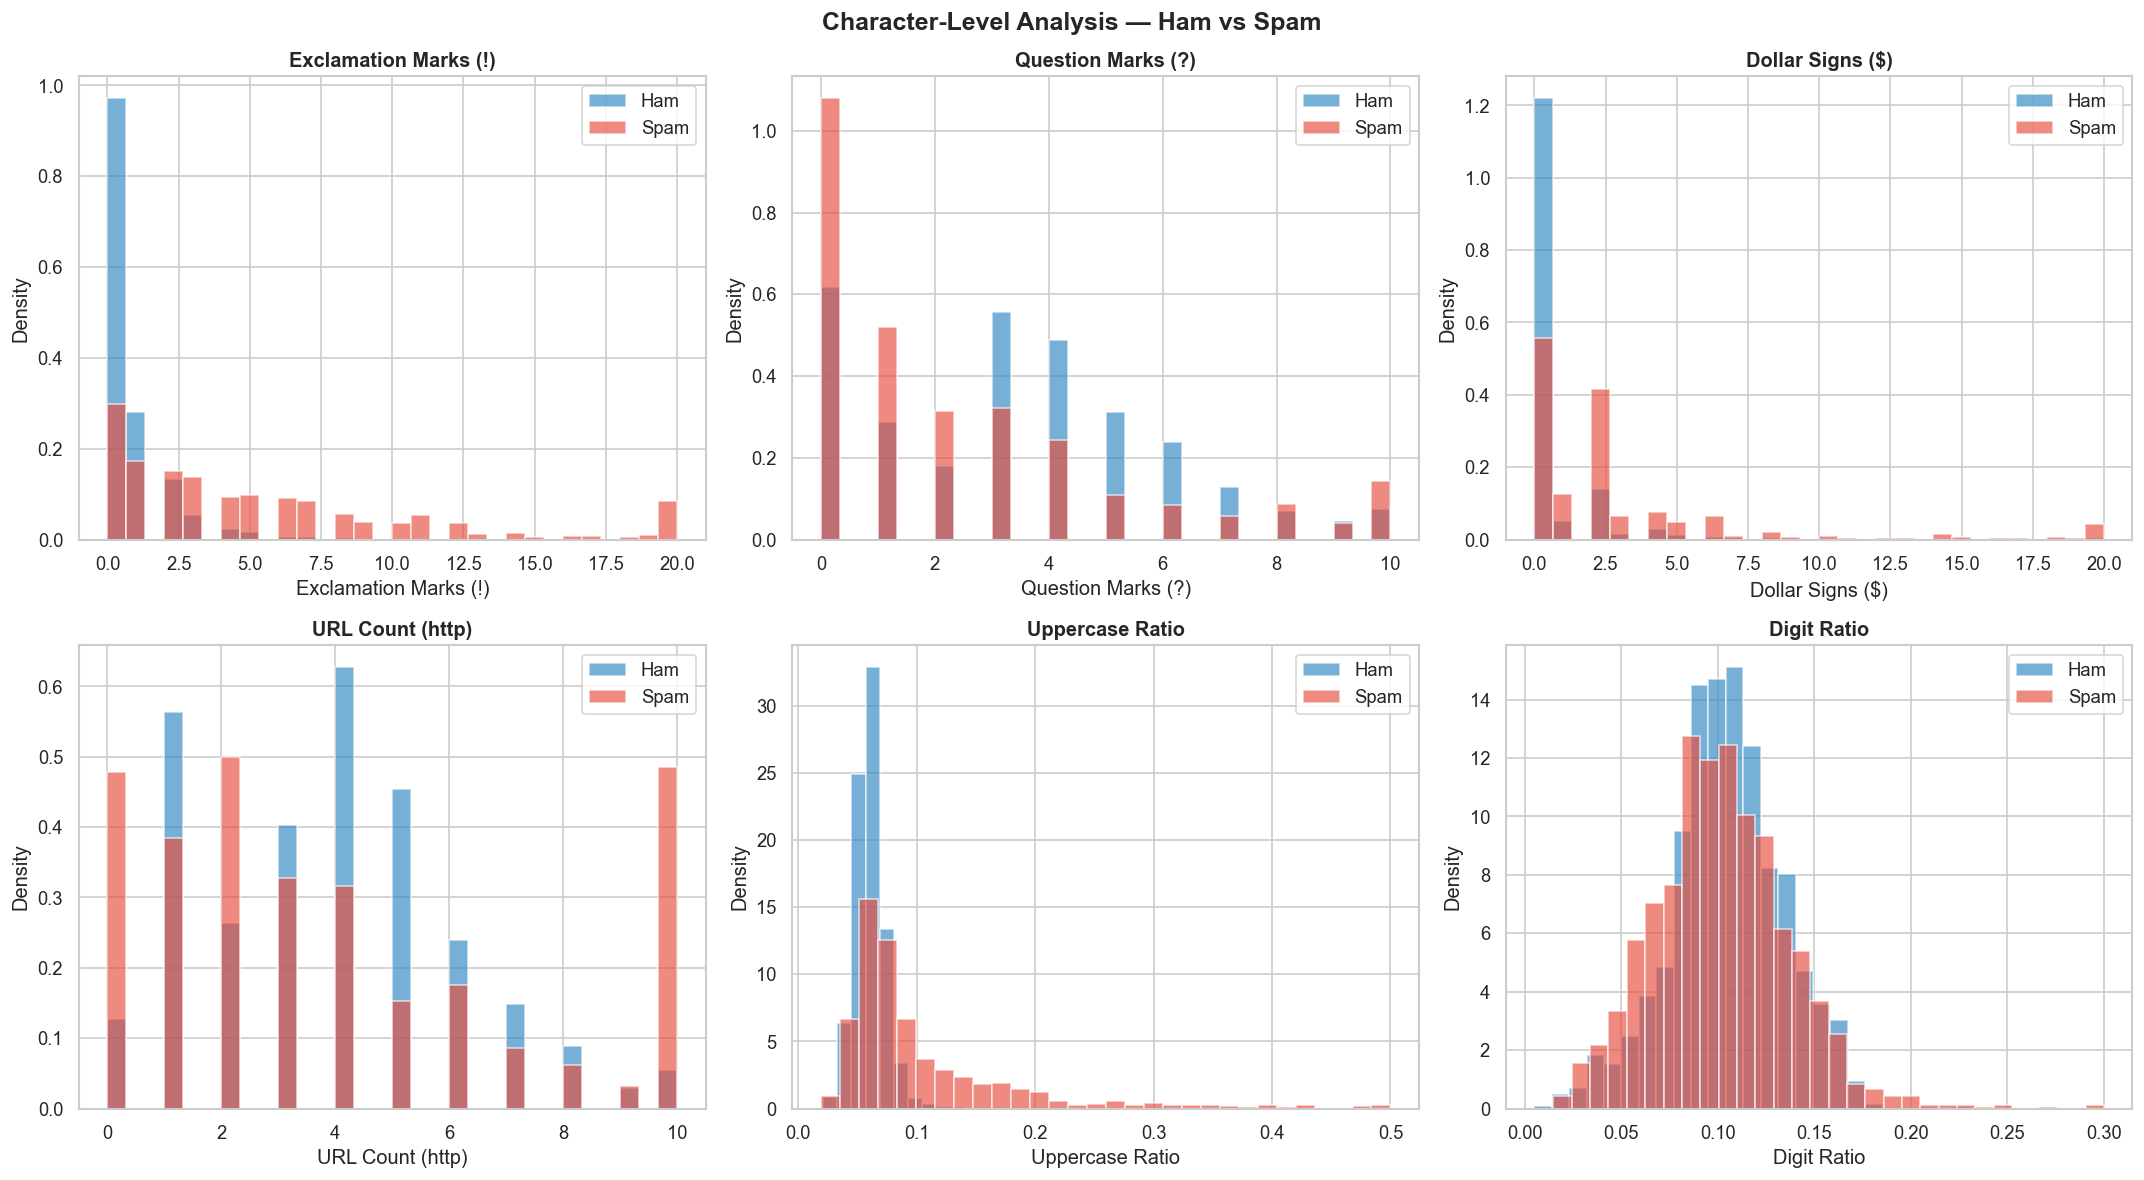

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

titles = ['Exclamation Marks (!)', 'Question Marks (?)',
          'Dollar Signs ($)', 'URL Count (http)',
          'Uppercase Ratio', 'Digit Ratio']
caps   = [20, 10, 20, 10, 0.5, 0.3]

for ax, col, title, cap in zip(axes.flat, char_features, titles, caps):
    for label, color in [('Ham', HAM_COLOR), ('Spam', SPAM_COLOR)]:
        data = df[df['label']==label][col].clip(upper=cap)
        ax.hist(data, bins=30, alpha=0.65, color=color,
                label=label, edgecolor='white', density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Character-Level Analysis — Ham vs Spam', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_char_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Top Most Frequent Words <a id='7'></a>

In [11]:
def get_top_words(texts, n=30, remove_stops=True):
    """Get top n most frequent words from a list of texts."""
    all_words = []
    for text in texts:
        words = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower()).split()
        if remove_stops:
            words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

ham_words  = get_top_words(df[df['label']=='Ham']['text'],  n=25)
spam_words = get_top_words(df[df['label']=='Spam']['text'], n=25)

print('Top 10 Ham Words:')
for w, c in ham_words[:10]: print(f'  {w:<20} {c:,}')
print()
print('Top 10 Spam Words:')
for w, c in spam_words[:10]: print(f'  {w:<20} {c:,}')

Top 10 Ham Words:
  com                  43,244
  org                  33,824
  net                  31,606
  localhost            25,991
  list                 24,632
  received             23,647
  spamassassin         19,802
  fork                 18,623
  xent                 18,144
  taint                14,649

Top 10 Spam Words:
  font                 42,222
  com                  27,580
  size                 15,332
  face                 11,463
  color                11,366
  http                 11,273
  width                10,973
  net                  10,969
  nbsp                 10,852
  received             8,718


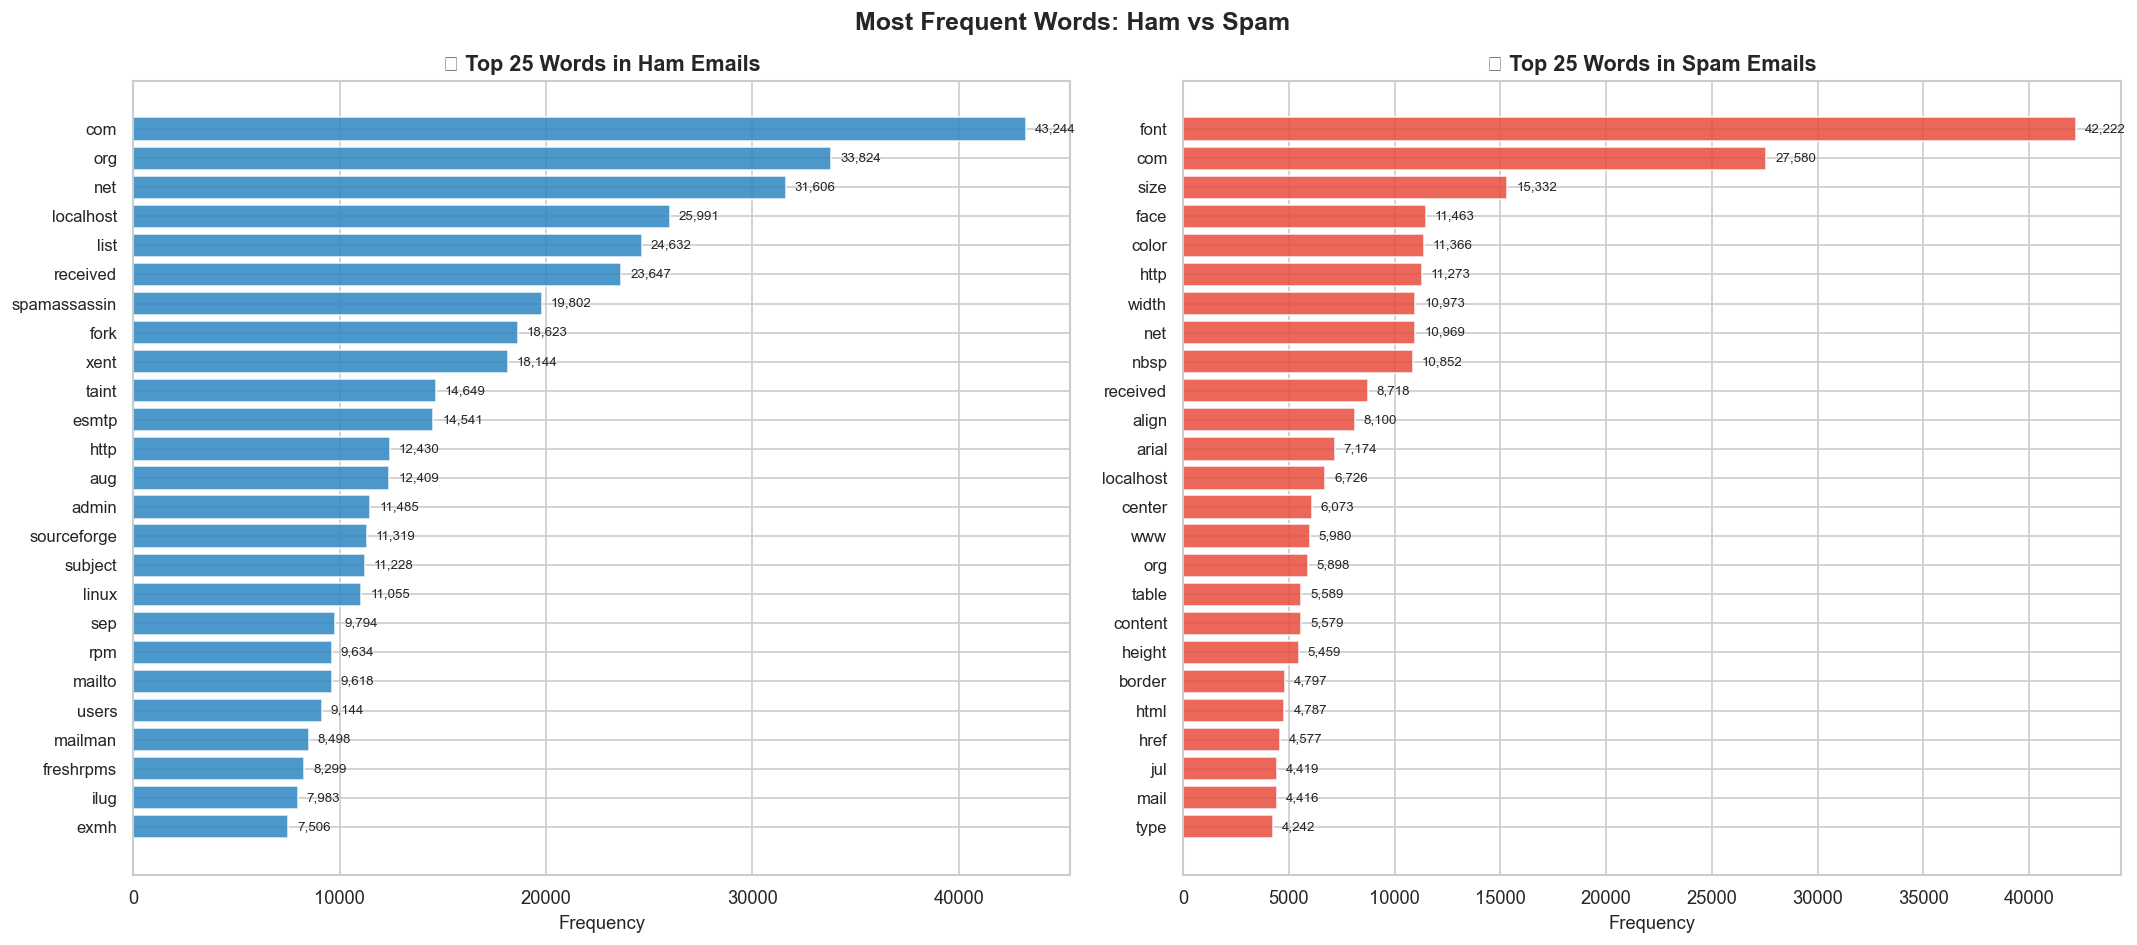

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, words, color, title in [
    (axes[0], ham_words,  HAM_COLOR,  '📬 Top 25 Words in Ham Emails'),
    (axes[1], spam_words, SPAM_COLOR, '🚨 Top 25 Words in Spam Emails'),
]:
    labels = [w for w, _ in words]
    values = [c for _, c in words]
    colors_bar = [color] * len(labels)
    
    bars = ax.barh(range(len(labels)), values[::-1],
                   color=colors_bar, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels[::-1], fontsize=10)
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)
    
    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('Most Frequent Words: Ham vs Spam', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_top_words.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Word Cloud <a id='8'></a>

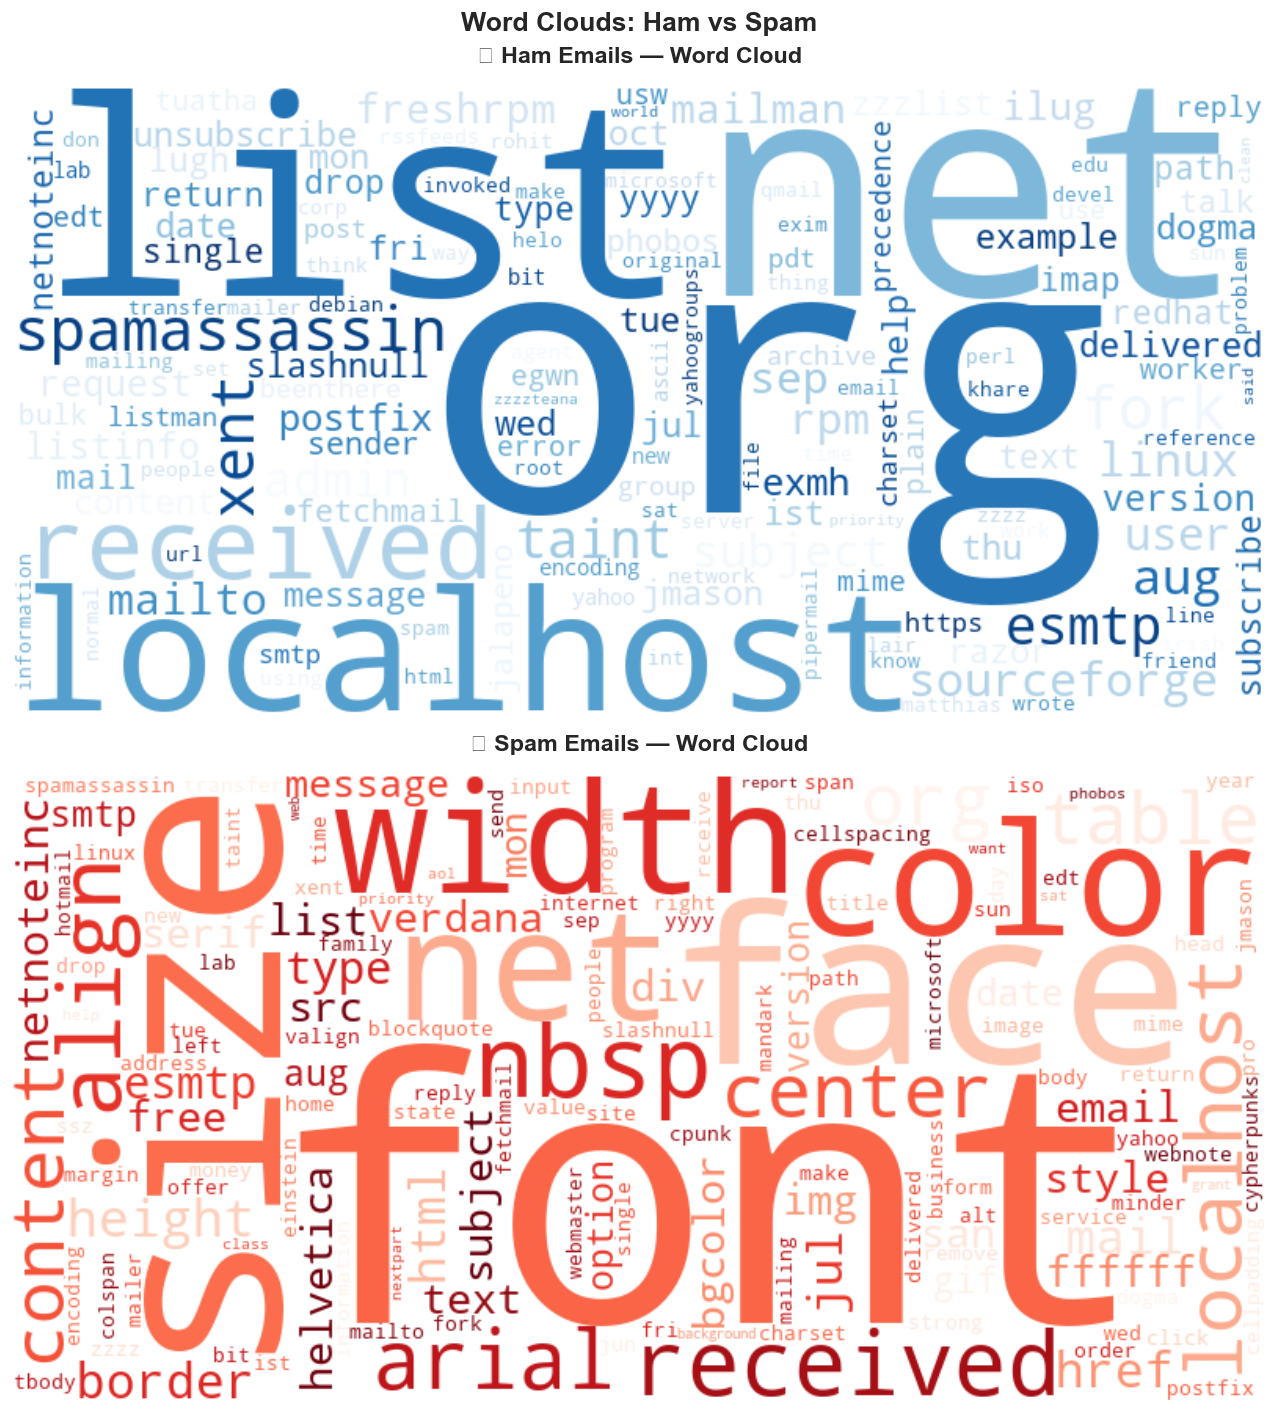

In [15]:
def make_wordcloud(texts, color, title, ax):
    combined = ' '.join(texts)
    combined = re.sub(r'[^a-zA-Z\s]', ' ', combined.lower())
    words    = [w for w in combined.split()
                if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    text_clean = ' '.join(words)
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='Blues' if color == HAM_COLOR else 'Reds',
        max_words=150,
        collocations=False,
    ).generate(text_clean)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

make_wordcloud(df[df['label']=='Ham']['text'].tolist(),
               HAM_COLOR, '📬 Ham Emails — Word Cloud', axes[0])
make_wordcloud(df[df['label']=='Spam']['text'].tolist(),
               SPAM_COLOR, '🚨 Spam Emails — Word Cloud', axes[1])

plt.suptitle('Word Clouds: Ham vs Spam', fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig('eda_07_wordcloud.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Unique Words Analysis <a id='9'></a>

Ham  vocabulary  : 38,552 unique words
Spam vocabulary  : 92,692 unique words
Words only in Ham  : 29,134
Words only in Spam : 83,274
Words in Common    : 9,418


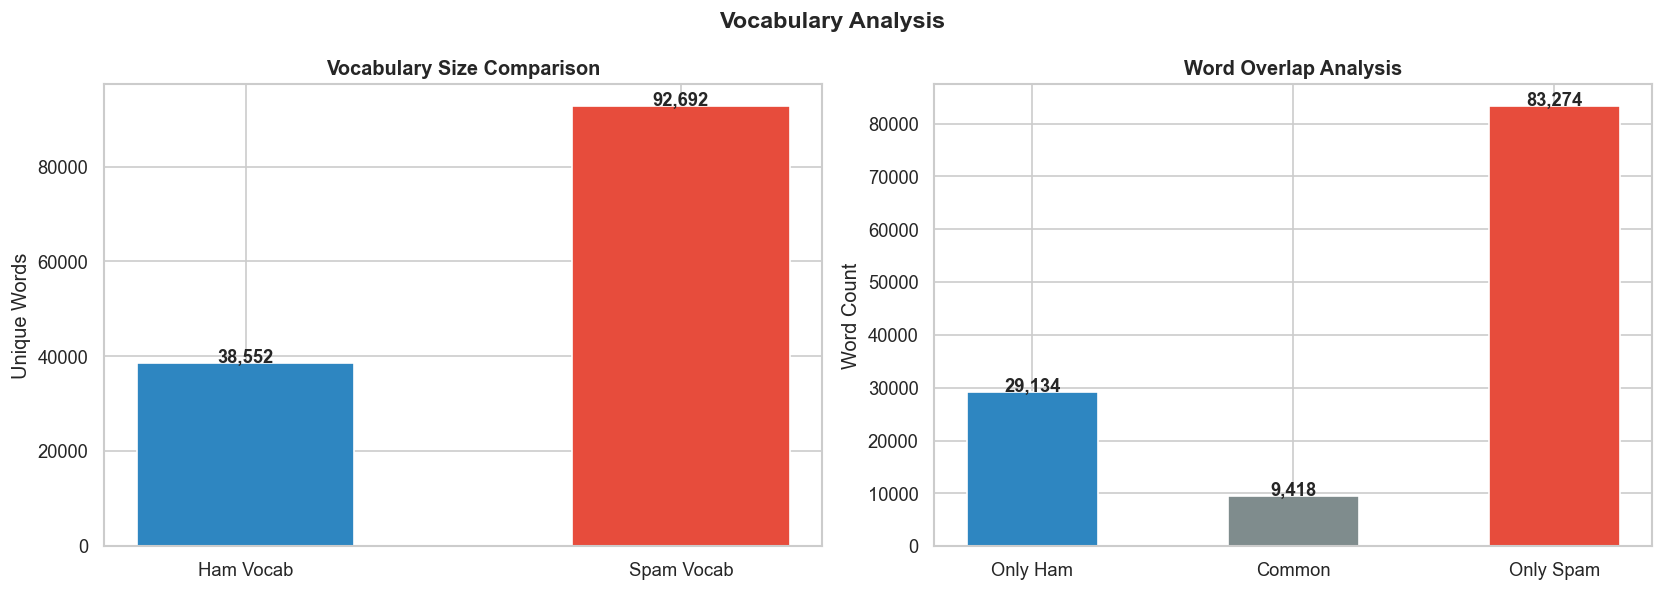


Sample words ONLY in Spam:
['chjfkgaaquurp', 'agluzyboyxbwzw', 'xoxo', 'nobtj', 'rijykj', 'shzcf', 'libxagvu', 'diksmicaiirpbzectgjqrygdctlgiqkdkavfgkbetajsaawagp', 'rotzw', 'nowbvqgh', 'kumvwywlyignyzwrpdcbwcm', 'gizawmk', 'pnxbn', 'dgaocoksg', 'miiiiij', 'rahnp', 'cziheq', 'bejx', 'kdqpdagvjaybpdxq', 'dqpt']

Sample words ONLY in Ham:
['clarebutler', 'kiva', 'trusts', 'mychipdesign', 'lingering', 'toliman', 'sccmmhc', 'gsxy', 'wmdg', 'applet', 'wheeze', 'pfryx', 'albasmith', 'noorg', 'kbdn', 'tabraham', 'exclusionary', 'economized', 'boquist', 'antiword']


In [16]:
# Vocabulary unique to each class
def get_word_set(texts):
    all_words = set()
    for text in texts:
        words = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower()).split()
        words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 3]
        all_words.update(words)
    return all_words

ham_vocab  = get_word_set(df[df['label']=='Ham']['text'])
spam_vocab = get_word_set(df[df['label']=='Spam']['text'])

only_ham   = ham_vocab  - spam_vocab
only_spam  = spam_vocab - ham_vocab
common     = ham_vocab  & spam_vocab

print(f'Ham  vocabulary  : {len(ham_vocab):,} unique words')
print(f'Spam vocabulary  : {len(spam_vocab):,} unique words')
print(f'Words only in Ham  : {len(only_ham):,}')
print(f'Words only in Spam : {len(only_spam):,}')
print(f'Words in Common    : {len(common):,}')

# Venn-style bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vocabulary size comparison
sizes  = [len(ham_vocab), len(spam_vocab)]
labels = ['Ham Vocab', 'Spam Vocab']
colors = [HAM_COLOR, SPAM_COLOR]
bars   = axes[0].bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Vocabulary Size Comparison', fontweight='bold')
axes[0].set_ylabel('Unique Words')
for bar, val in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')

# Overlap
overlap_data = [len(only_ham), len(common), len(only_spam)]
overlap_labels = ['Only Ham', 'Common', 'Only Spam']
overlap_colors = [HAM_COLOR, '#7F8C8D', SPAM_COLOR]
bars2 = axes[1].bar(overlap_labels, overlap_data, color=overlap_colors,
                    edgecolor='white', width=0.5)
axes[1].set_title('Word Overlap Analysis', fontweight='bold')
axes[1].set_ylabel('Word Count')
for bar, val in zip(bars2, overlap_data):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold')

plt.suptitle('Vocabulary Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_vocabulary.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSample words ONLY in Spam:')
print(list(only_spam)[:20])
print('\nSample words ONLY in Ham:')
print(list(only_ham)[:20])

---
## 10. Punctuation & Special Characters <a id='10'></a>

Average Special Character Usage per Email:
       exclaim_count  question_count  dollar_count  url_count
label                                                        
Ham             0.72            3.35          0.70       3.83
Spam            6.41            2.67          3.91       6.19


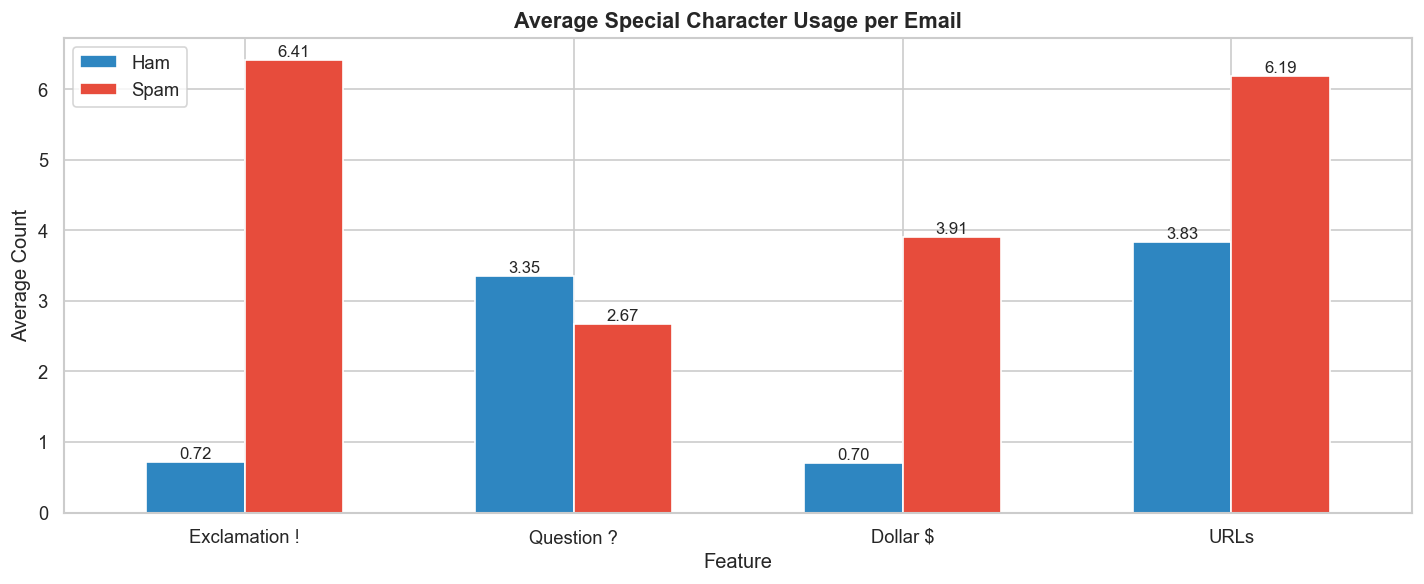

In [17]:
# Average special char usage per email
special_means = df.groupby('label')[['exclaim_count','question_count',
                                      'dollar_count','url_count']].mean().round(2)

print('Average Special Character Usage per Email:')
print(special_means.to_string())

ax = special_means.T.plot(
    kind='bar', figsize=(12, 5),
    color=[HAM_COLOR, SPAM_COLOR],
    edgecolor='white', width=0.6
)
ax.set_title('Average Special Character Usage per Email', fontweight='bold', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Average Count')
ax.set_xticklabels(['Exclamation !', 'Question ?', 'Dollar $', 'URLs'],
                    rotation=0, fontsize=11)
ax.legend(['Ham', 'Spam'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_09_special_chars.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Email Header Analysis <a id='11'></a>

In [18]:
# Extract common email header signals
df['has_html']        = df['text'].str.contains(r'<html|<HTML|<body|<BODY',
                                                  regex=True).astype(int)
df['has_unsubscribe'] = df['text'].str.contains(r'unsubscribe|UNSUBSCRIBE',
                                                  regex=True).astype(int)
df['has_free']        = df['text'].str.contains(r'\bfree\b|\bFREE\b',
                                                  regex=True).astype(int)
df['has_click']       = df['text'].str.contains(r'\bclick\b|\bCLICK\b',
                                                  regex=True).astype(int)
df['has_winner']      = df['text'].str.contains(r'\bwinner\b|\bWINNER\b|\bwon\b',
                                                  regex=True).astype(int)
df['has_offer']       = df['text'].str.contains(r'\boffer\b|\bOFFER\b',
                                                  regex=True).astype(int)
df['has_urgent']      = df['text'].str.contains(r'urgent|URGENT|immediately',
                                                  regex=True).astype(int)
df['has_money']       = df['text'].str.contains(r'\$|money|MONEY|cash|CASH',
                                                  regex=True).astype(int)

signal_cols = ['has_html','has_unsubscribe','has_free','has_click',
               'has_winner','has_offer','has_urgent','has_money']

signal_pct = df.groupby('label')[signal_cols].mean() * 100
print('% of Emails Containing Each Signal:')
print(signal_pct.round(1).to_string())

% of Emails Containing Each Signal:
       has_html  has_unsubscribe  has_free  has_click  has_winner  has_offer  has_urgent  has_money
label                                                                                              
Ham         0.6             61.8       9.7       11.5         4.8        1.8         2.4       21.5
Spam       52.3             22.2      39.9       38.1         4.3       15.9         7.5       70.1


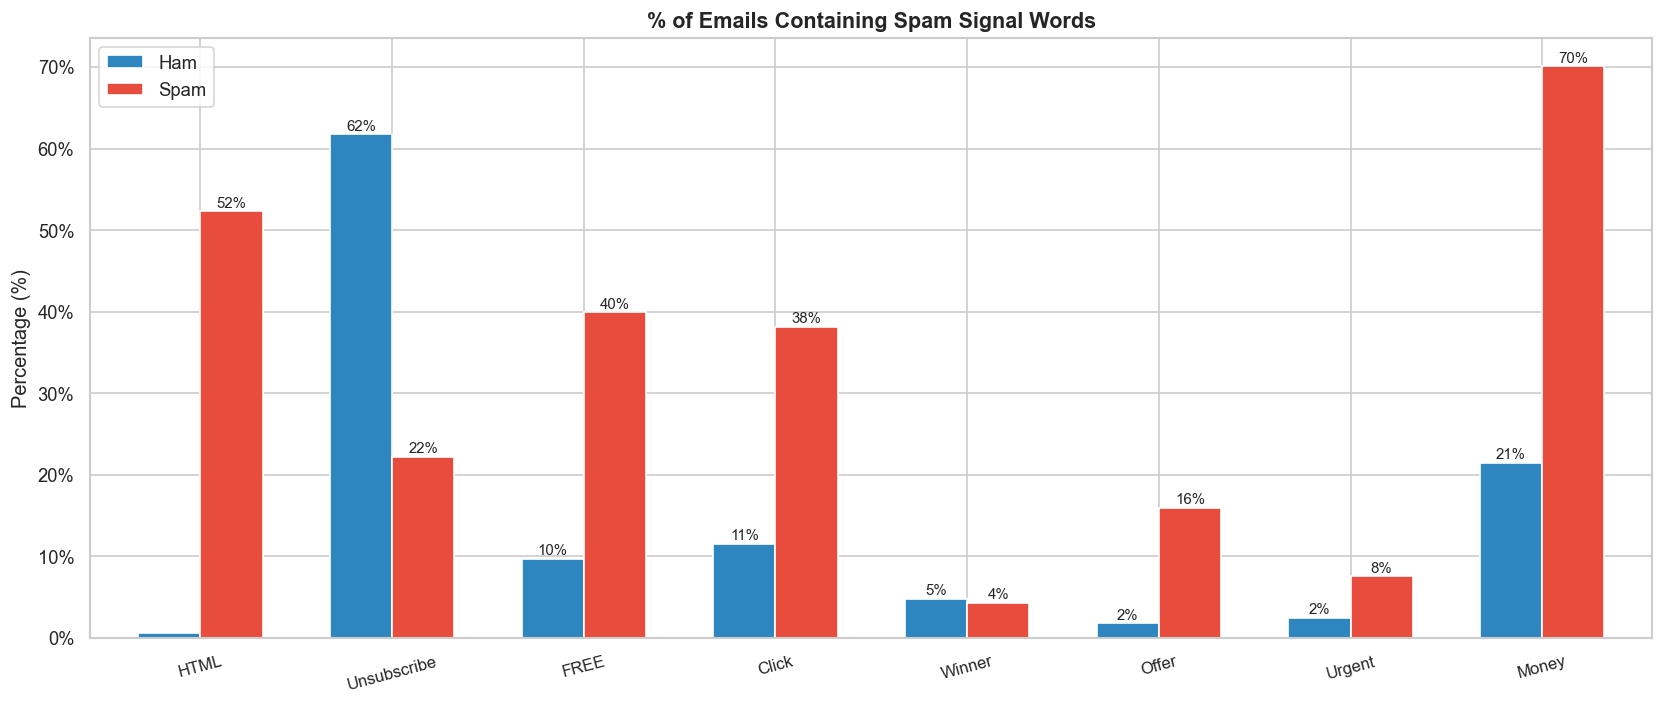

In [19]:
ax = signal_pct.T.plot(
    kind='bar', figsize=(14, 6),
    color=[HAM_COLOR, SPAM_COLOR],
    edgecolor='white', width=0.65
)
ax.set_title('% of Emails Containing Spam Signal Words', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(['HTML','Unsubscribe','FREE','Click',
                     'Winner','Offer','Urgent','Money'],
                    rotation=15, fontsize=10)
ax.legend(['Ham', 'Spam'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for p in ax.patches:
    if p.get_height() > 1:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                    ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_10_spam_signals.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Correlation & Summary <a id='12'></a>

Feature Correlation with Target (Spam=1):
has_unsubscribe     -0.3713
question_count      -0.0784
digit_ratio         -0.0492
unique_word_ratio   -0.0318
sent_count          -0.0225
has_winner          -0.0117
url_count            0.0993
has_urgent           0.1216
word_count           0.1230
char_count           0.1743
dollar_count         0.1749
avg_word_len         0.2122
has_offer            0.2714
has_click            0.3113
has_free             0.3579
exclaim_count        0.3895
upper_ratio          0.3979
has_money            0.4716
has_html             0.6374
line_count              NaN


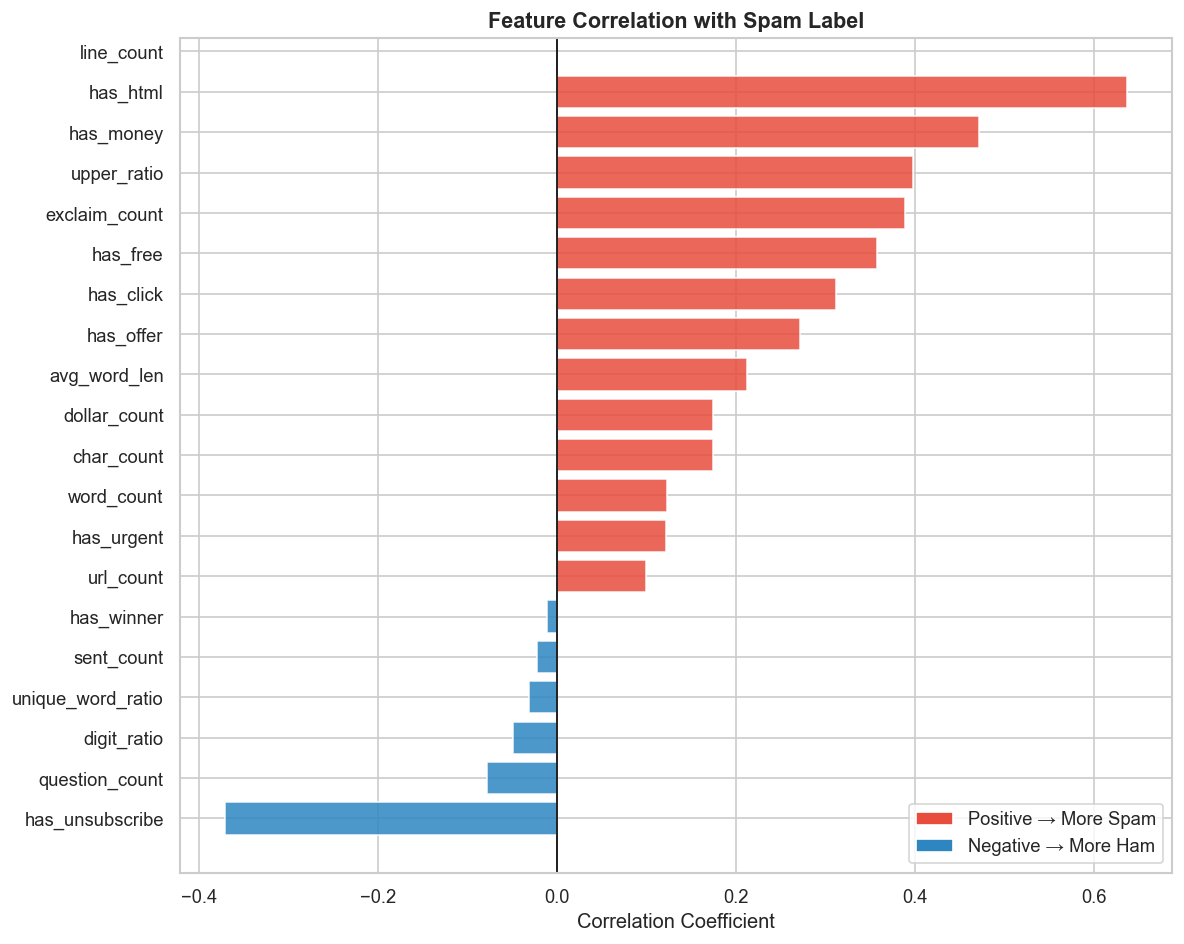

In [20]:
# Correlation of all numeric features with target
numeric_cols = ['char_count','word_count','line_count','sent_count',
                'avg_word_len','unique_word_ratio','upper_ratio','digit_ratio',
                'exclaim_count','question_count','dollar_count','url_count',
                'has_html','has_unsubscribe','has_free','has_click',
                'has_winner','has_offer','has_urgent','has_money']

corr = df[numeric_cols + ['target']].corr()['target'].drop('target').sort_values()

print('Feature Correlation with Target (Spam=1):')
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = [SPAM_COLOR if v > 0 else HAM_COLOR for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Feature Correlation with Spam Label', fontweight='bold', fontsize=13)
ax.set_xlabel('Correlation Coefficient')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SPAM_COLOR, label='Positive → More Spam'),
                   Patch(facecolor=HAM_COLOR,  label='Negative → More Ham')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('eda_11_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

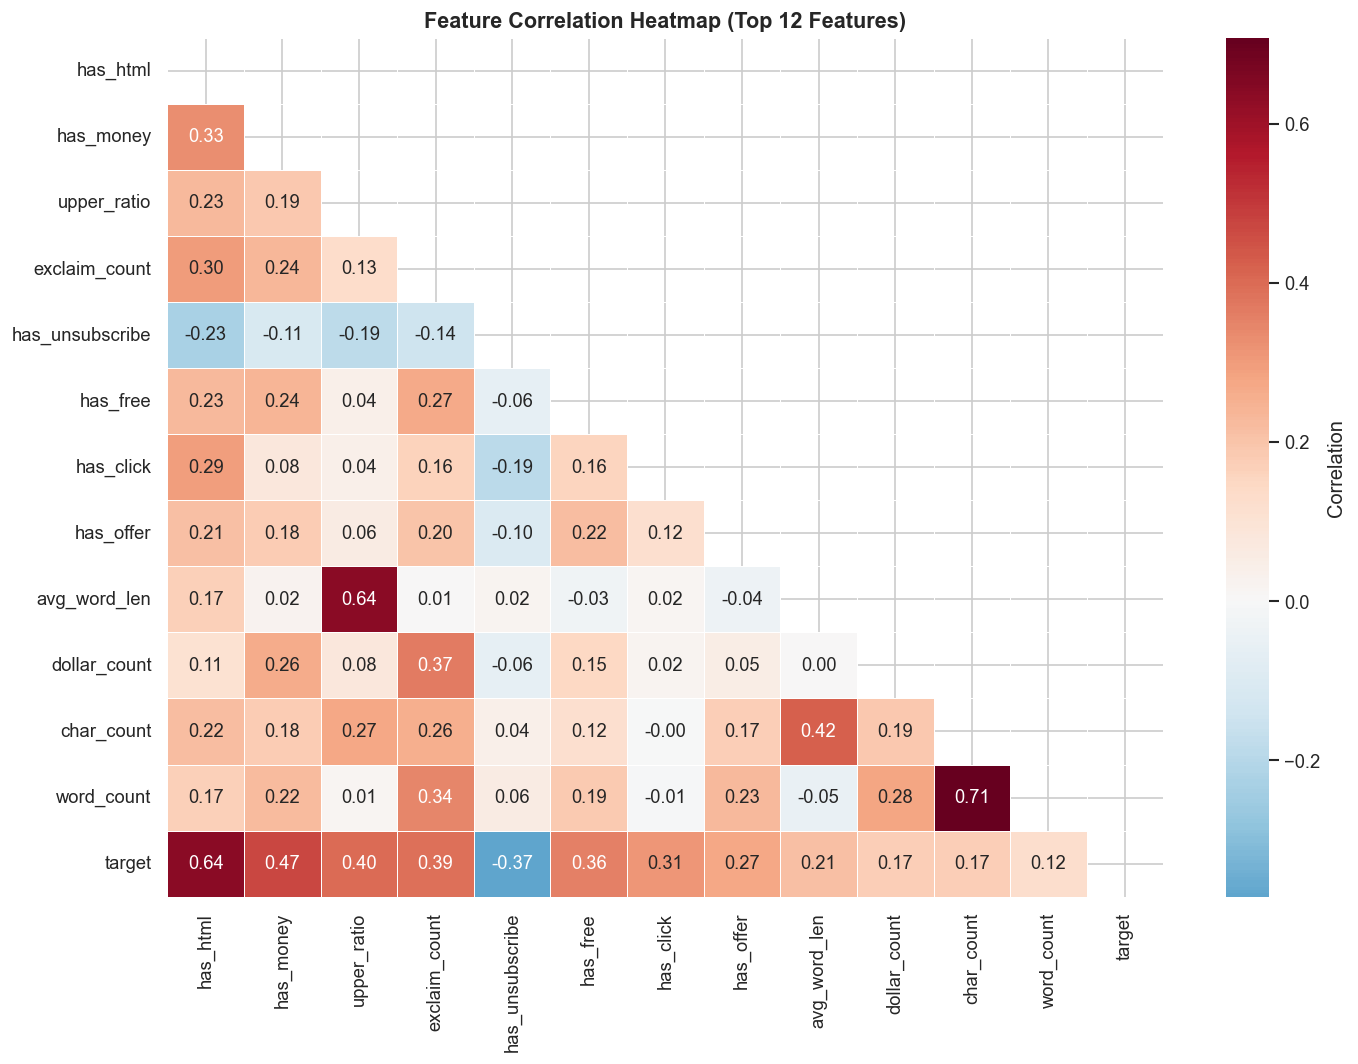

In [21]:
# Correlation heatmap (top features)
top_features = corr.abs().nlargest(12).index.tolist() + ['target']

plt.figure(figsize=(12, 9))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap (Top 12 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_12_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
# Final EDA Summary
print('='*60)
print('           EDA SUMMARY — SpamAssassin Dataset')
print('='*60)
print(f'Total Emails        : {len(df):,}')
print(f'Ham Emails          : {(df["target"]==0).sum():,}  (67.3%)')
print(f'Spam Emails         : {(df["target"]==1).sum():,}  (32.7%)')
print(f'Imbalance Ratio     : 2.06 : 1')
print()
print('Average Email Length:')
print(f'  Ham  → {df[df["target"]==0]["char_count"].mean():,.0f} chars | {df[df["target"]==0]["word_count"].mean():,.0f} words')
print(f'  Spam → {df[df["target"]==1]["char_count"].mean():,.0f} chars | {df[df["target"]==1]["word_count"].mean():,.0f} words')
print()
print('Top Spam Signals (% present in Spam emails):')
for col in ['has_html','has_free','has_money','has_click','has_unsubscribe']:
    pct = df[df['target']==1][col].mean()*100
    print(f'  {col:<20} {pct:.1f}%')
print()
print('Strongest Correlations with Spam:')
for feat, val in corr.abs().nlargest(5).items():
    direction = '↑ Spam' if corr[feat] > 0 else '↓ Ham'
    print(f'  {feat:<25} {corr[feat]:+.4f}  {direction}')
print('='*60)

           EDA SUMMARY — SpamAssassin Dataset
Total Emails        : 5,796
Ham Emails          : 3,900  (67.3%)
Spam Emails         : 1,896  (32.7%)
Imbalance Ratio     : 2.06 : 1

Average Email Length:
  Ham  → 3,483 chars | 406 words
  Spam → 5,667 chars | 546 words

Top Spam Signals (% present in Spam emails):
  has_html             52.3%
  has_free             39.9%
  has_money            70.1%
  has_click            38.1%
  has_unsubscribe      22.2%

Strongest Correlations with Spam:
  has_html                  +0.6374  ↑ Spam
  has_money                 +0.4716  ↑ Spam
  upper_ratio               +0.3979  ↑ Spam
  exclaim_count             +0.3895  ↑ Spam
  has_unsubscribe           -0.3713  ↓ Ham
